### Importamos las librerías necesarias

In [6]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
from collections import deque
import random
import pygame
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from snake import SnakeEnv
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


### Prueba del entorno con un `Agente Aleatorio`:

In [18]:
if __name__ == "__main__":
    env = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
    obs, info = env.reset()
 
    total_reward = 0
    episodio = 1
 
    print(f"{'Episodio':>9} | {'Recompensa':>10} | {'Longitud':>8} | Causa fin")
    print("-" * 55)
 
    while env.running:
        action = env.action_space.sample() # Elige una acción aleatoria entre [0, 1, 2]
 
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
 
        env.render()
 
        if terminated or truncated:
            causa = info.get("cause") or "max_steps"
            print(f"{episodio:>9} | {total_reward:>10.2f} | {len(env.snake):>8} | {causa}")
            episodio += 1
            total_reward = 0
            obs, info = env.reset()
 
    env.close()


 Episodio | Recompensa | Longitud | Causa fin
-------------------------------------------------------
        1 |     -20.91 |        3 | collision
        2 |     -20.00 |        4 | bad_food
        3 |     -20.90 |        3 | collision
        4 |     -20.38 |        3 | obstacle
        5 |     -20.35 |        3 | collision
        6 |     -19.63 |        3 | collision
        7 |     -20.37 |        3 | obstacle
        8 |     -19.99 |        3 | collision
        9 |     -19.75 |        3 | obstacle
       10 |     -20.30 |        3 | collision
       11 |     -19.66 |        4 | bad_food
       12 |     -19.77 |        3 | collision
       13 |     -20.55 |        3 | obstacle
       14 |     -20.04 |        3 | obstacle
       15 |     -20.17 |        3 | collision


### Prueba del entorno para controlar `manualmente`:

In [4]:
if __name__ == "__main__":
    env = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
    obs, info = env.reset()

    env.render()
    
    # Mapeo de teclas a direcciones absolutas (0: Arriba, 1: Derecha, 2: Abajo, 3: Izquierda)
    KEY_TO_DIR = {
        pygame.K_UP: 0,
        pygame.K_RIGHT: 1,
        pygame.K_DOWN: 2,
        pygame.K_LEFT: 3
    }
    
    while env.running:
        # Gestiona la velocidad para que un humano pueda jugar
        env.clock.tick(10)

        # Por defecto, la acción es 1 (seguir recto)
        action = 1 
        
        # Capturamos eventos de teclado
        pygame.event.pump()
        keys = pygame.key.get_pressed()
        
        # Determina qué dirección absoluta quiere el usuario
        desired_dir = -1
        for key, direction in KEY_TO_DIR.items():
            if keys[key]:
                desired_dir = direction
                break
        
        # Traduce la dirección absoluta a acción relativa (giro)
        if desired_dir != -1:
            current_dir = env.direction
            
            # Calculamos la diferencia de giro
            diff = (desired_dir - current_dir) % 4
            
            if diff == 3: # Ir a la izquierda
                action = 0
            elif diff == 1: # Ir a la derecha
                action = 2
            elif diff == 0: # Misma dirección
                action = 1

        # Aplica la acción en el entorno
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()

        # Reinicio si muere
        if terminated or truncated:
            print(f"Fin del juego. Causa: {info.get('cause')}.")
            obs, info = env.reset()

    env.close()

Fin del juego. Causa: collision.
Fin del juego. Causa: obstacle.
Fin del juego. Causa: bad_food.
Fin del juego. Causa: collision.


### Entrenamiento de Agentes:
Para el entrenamiento de agentes, nos centraremos en tres métodos principalmente: ``Monte Carlo``, ``Q-Learning`` y ``Deep Q-Learning``.

Antes de empezar a entrenar a nuestros agentes, debemos tener en cuenta que la lista de observaciones que nos devuelve **_get_obsertions** ya viene normalizada a excepción del último valor ``length_norm``. Dicho valor es continuo, lo que significa que hay infinitos valores distintos y como el agente visitaría cada estado 1 sola vez, la tabla Q nunca convergiría y el agente no llegaría a aprender. Para solucionar esto, vamos a discretizar este valor para que la tabla pueda converger.

In [7]:
N_BINS = 10

def discretizar_estado(obs: np.ndarray, n_bins = N_BINS) -> tuple:
    """
    Convierte el vector de observación continuo en una tupla hashable
    que puede usarse como clave en la tabla Q.

    Las primeras 13 features que son binarias se convierten a int directamente.
    La feature 13 (length_norm) se discretiza en n_bins intervalos uniformes.
    """
    # Features binarias
    estado_discreto = tuple(int(round(x)) for x in obs[:13])

    # Feature continua: bin entre 0 y n_bins-1
    bin_longitud = min(int(obs[13] * n_bins), n_bins - 1)

    return estado_discreto + (bin_longitud,)


# Verificación rápida
env_test = SnakeEnv()
obs, _ = env_test.reset()
estado = discretizar_estado(obs)
print(f"Observación original (14 floats): {obs}")
print(f"Estado discretizado  (14 ints)  : {estado}")
print(f"Tipo de la clave: {type(estado)}")

Observación original (14 floats): [0.   0.   0.   0.   1.   0.   0.   0.   1.   0.   0.   0.   0.   0.03]
Estado discretizado  (14 ints)  : (0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0)
Tipo de la clave: <class 'tuple'>


## Monte Carlo


Definimos dos funciones para este método: `elegir_accion_epsilon_greedy` emplea una política epsilon-greedy según el valor *epsilon* pasado como parámetro; y `monte_carlo_control` entrena un agente mediante el método de Monte Carlo y devuelve la tabla Q y el histórico de recompensas.

In [ ]:
def elegir_accion_epsilon_greedy(estado: int, Q: defaultdict, epsilon: float, n_acciones: 3) -> int:
    """
    Recibe un estado y una tabla Q y devuelve una acción usando una
    política epsilon-greedy. Si el estado no existe en Q, se inicializa en 0.
    """

    # Exploración: elige una acción aleatoria con probabilidad epsilon
    if np.random.random() < epsilon:
        return int(np.random.choice(n_acciones))

    # Explotación: toma la acción que maximiza el valor Q 
    return int(np.argmax(Q[estado]))


def monte_carlo_control(env: SnakeEnv, num_episodios: int, trace: int, epsilon: float, gamma: float):
    """
    Entrena un agente usando el método de Control de Monte Carlo.
    """

    # Tabla Q: cada estado tiene un array de 3 ceros (uno por acción)
    Q = defaultdict(lambda: np.zeros(env.action_space.n))

    # Contador de visitas a cada par estado-acción
    visitas = defaultdict(lambda: np.zeros(env.action_space.n))

    historico_recompensas = []

    for i in range(num_episodios):
        episodio = []
        obs, _ = env.reset()
        estado = discretizar_estado(obs)
        terminado = False
        truncado = False
        recompensa_total_episodio = 0

        # Genera un episodio completo
        while not (terminado or truncado):
            accion = elegir_accion_epsilon_greedy(estado, Q, epsilon)
            proxima_obs, recompensa, terminado, truncado, _ = env.step(accion)
            
            # Guardamos la transición
            episodio.append((estado, accion, recompensa))
            
            estado = discretizar_estado(proxima_obs)
            recompensa_total_episodio += recompensa

        historico_recompensas.append(recompensa_total_episodio)

        # Actualización de la tabla Q
        G = 0

        # Recorremos el episodio a la inversa para calcular los retornos
        for t in reversed(range(len(episodio))):
            est, acc, rec = episodio[t]
            G = rec + gamma * G
            
            # Calcula la media iterativa
            visitas[est][acc] += 1
            n = visitas[est][acc]
            Q[est][acc] += (1 / n) * (G - Q[est][acc])

        if (i + 1) % trace == 0:
            print(f"Episodio {i+1}/{num_episodios} | Recompensa media: {np.mean(historico_recompensas[-trace:]):.2f}")

    return Q, historico_recompensas


### Entrenamiento del modelo
Para este caso, vamos a entrenar varios agentes probando diferentes valores de epsilon `[0.2, 0.1, 0.05, 0.01, 0]`. Vamos a utilizar la librería `joblib` para aprovechar los núcleos del procesador y entrenar los agentes en paralelo:

In [20]:
from joblib import Parallel, delayed

# Función auxiliar para ejecutar un entrenamiento individual
def ejecutar_experimento(num_episodios, trace, epsilon, gamma):
    env = SnakeEnv()
    Q, historico_recompensas = monte_carlo_control(env=env, num_episodios=num_episodios,
                                                   trace=trace, epsilon=epsilon, gamma=gamma)
    env.close()
    return epsilon, Q, historico_recompensas


if __name__ == "__main__":
    # Parámetros de los experimentos
    epsilons = [0.2, 0.1, 0.05, 0.01, 0]
    num_episodios = 500_000
    trace = 100
    gamma = 0.99

    # Creamos un Pool de procesos para paralelizar los entrenamientos con diferentes epsilons
    resultados = Parallel(n_jobs=-1)(
        delayed(ejecutar_experimento)(num_episodios, trace, eps, gamma) for eps in epsilons)

    # Organizamos los resultados en diccionarios para su análisis posterior
    Qs = {}
    recompensas = {}
    for eps, q_res, hist_res in resultados:
        Qs[eps] = q_res
        recompensas[eps] = hist_res


### Evolución del entrenamiento
Una vez entrenados todos los agentes, vamos a visualizar en un gráfico cómo ha evolucionado la recompensa de los agentes con el paso de los episodios:

c:\Users\jcarr\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


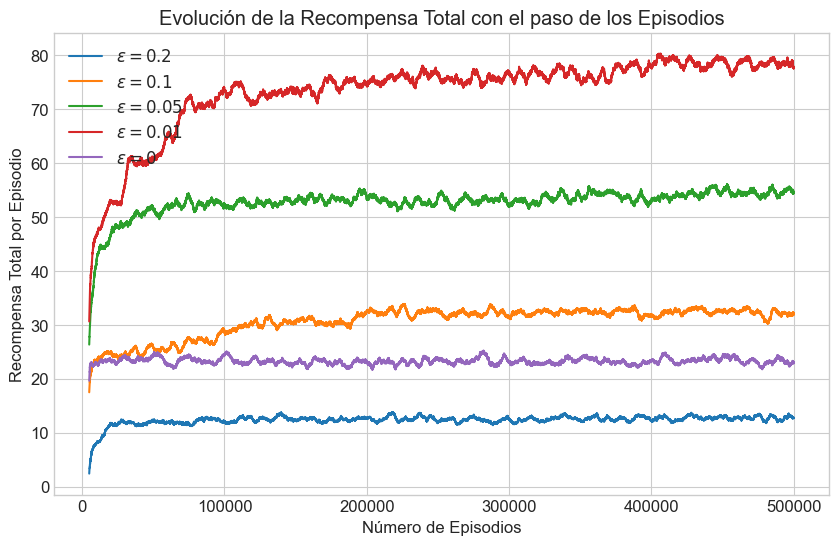

In [24]:
# Configuración de estilo para gráficas (opcional, mejora la estética)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

ventana = num_episodios // 100

# Gráfica
plt.figure(figsize=(10, 6))

for epsilon, recompensas_eps in recompensas.items():
    recompensas_suavizadas = pd.Series(recompensas_eps).rolling(window=ventana).mean()
    plt.plot(recompensas_suavizadas, label=rf'$\epsilon={epsilon}$')

plt.xlabel('Número de Episodios')
plt.ylabel('Recompensa Total por Episodio')
plt.title('Evolución de la Recompensa Total con el paso de los Episodios')
plt.legend()
plt.grid(True)
plt.show()

### Visualización de como juega el Agente

In [25]:
if __name__ == "__main__":
    env = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
    obs, info = env.reset()
 
    total_reward = 0
    episodio = 1
 
    print(f"{'Episodio':>9} | {'Recompensa':>10} | {'Longitud':>8} | Causa fin")
    print("-" * 55)
 
    while env.running:
        # Política aprendida: elige la acción con mayor valor Q para el estado actual
        action = int(np.argmax(Qs[0.01][discretizar_estado(obs)]))
 
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
 
        env.render()
 
        if terminated or truncated:
            causa = info.get("cause") or "max_steps"
            print(f"{episodio:>9} | {total_reward:>10.2f} | {len(env.snake):>8} | {causa}")
            episodio += 1
            total_reward = 0
            obs, info = env.reset()
 
    env.close()


 Episodio | Recompensa | Longitud | Causa fin
-------------------------------------------------------
        1 |     159.67 |       20 | collision
        2 |      53.99 |       10 | collision
        3 |      -9.75 |        4 | obstacle
        4 |      23.28 |        8 | bad_food
        5 |      74.82 |       12 | collision


## Q-learning

### Política Epsilon-Greedy

Usamos una política $\epsilon$-greedy:
- Con probabilidad $\epsilon$ → acción **aleatoria** (explorar)
- Con probabilidad $1-\epsilon$ → $\arg\max_a Q(s, a)$ (explotar)

En caso de empate entre los valores Q máximos, elegimos al azar entre los mejores para evitar un sesgo sistemático.

In [8]:
def elegir_accion(estado: tuple, Q: defaultdict, epsilon: float, n_acciones: int = 3) -> int:

    if np.random.random() < epsilon:
        return np.random.randint(n_acciones)

    q_valores = Q[estado]

    # Rompemos los empates aleatoriamente
    max_q   = np.max(q_valores)
    mejores = np.where(q_valores == max_q)[0]
    return int(np.random.choice(mejores))

Definimos una clase y una función para este método: la clase `AgenteQLearning` gestiona la actualización de la tabla Q e incluye una función de decaimiento del parámetro *epsilon*. La función `entrenamiento_Q_learning` entrena un agente mediante Q-Learning (con la fórmula incluída abajo) y devuelve una instancia del agente entrenado y un diccionario con algunas métricas del entrenamiento.

$$Q(s, a) \leftarrow Q(s, a) + \alpha \underbrace{\left( \underbrace{r + \gamma \cdot \max_{a'} Q(s', a')}_{\text{Objetivo TD}} - Q(s, a) \right)}_{\text{Error TD}}$$

In [9]:
class AgenteQLearning:

    def __init__(
        self,
        alpha: float = 0.1,
        gamma: float = 0.95,
        epsilon: float = 1.0,
        epsilon_min: float = 0.01,
        epsilon_decay: float = 0.995,
        n_acciones: int = 3,
    ):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_acciones = n_acciones

        # Tabla Q
        self.Q = defaultdict(lambda: np.zeros(self.n_acciones))

    def get_accion(self, observacion: np.ndarray) -> int:
        estado = discretizar_estado(observacion)
        return elegir_accion(estado, self.Q, self.epsilon, self.n_acciones)

    def actualizar_tabla_Q(self, observacion, accion, recompensa, obs_siguiente, terminado):
        s = discretizar_estado(observacion)
        s_ = discretizar_estado(obs_siguiente)
        max_q = np.max(self.Q[s_]) if not terminado else 0.0
        self.Q[s][accion] += self.alpha * (recompensa + self.gamma * max_q - self.Q[s][accion])

    def decay_epsilon(self):
        # Asignar el resultado a self.epsilon en lugar de solo devolverlo
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def estados_conocidos(self):
        return len(self.Q)

In [10]:
def entrenamiento_Q_learning(
        env,
        num_episodios = 10_000,
        alpha = 0.1,
        gamma = 0.95,
        epsilon = 1.0,
        epsilon_min = 0.01,
        epsilon_decay = 0.995,
        intervalo_log = 500):

    agente = AgenteQLearning(
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay,
    )

    metricas: dict = {
        "recompensas": [],
        "longitudes": [],
        "causas": [],
        "epsilons": [],
        "estados_Q": [],
    }

    print(f"{'Episodio':>10} | {'R. Media':>10} | {'Long. Media':>12} | {'Epsilon':>8} | {'Estados Q':>10}")
    print("-" * 62)

    for ep in range(1, num_episodios + 1):
        obs, _ = env.reset()
        recompensa_total = 0.0
        terminado = truncado = False

        while not (terminado or truncado):
            accion = agente.get_accion(obs)
            obs_sig, recompensa, terminado, truncado, info = env.step(accion)
            agente.actualizar_tabla_Q(obs, accion, recompensa, obs_sig, terminado or truncado)
            obs = obs_sig
            recompensa_total += recompensa

        agente.decay_epsilon()

        metricas["recompensas"].append(recompensa_total)
        metricas["longitudes"].append(len(env.snake))
        metricas["causas"].append(info.get("cause") or "max_steps")
        metricas["epsilons"].append(agente.epsilon)
        metricas["estados_Q"].append(agente.estados_conocidos())

        if ep % intervalo_log == 0:
            ventana_r = metricas["recompensas"][-intervalo_log:]
            ventana_l = metricas["longitudes"][-intervalo_log:]
            print(
                f"{ep:>10} | "
                f"{np.mean(ventana_r):>10.2f} | "
                f"{np.mean(ventana_l):>12.2f} | "
                f"{agente.epsilon:>8.4f} | "
                f"{agente.estados_conocidos():>10}"
            )

    print("\nEntrenamiento finalizado.")
    print(f"Estados únicos explorados: {agente.estados_conocidos()}")
    return agente, metricas

### Entrenamiento del modelo
Para este caso, vamos a entrenar un agente con decaimiento del parámetro *epsilon* para explorar inicialmente y después refinar las mejores estrategias encontradas.

In [24]:
env = SnakeEnv(grid_size=10, render_mode=None, max_steps=500)

agente, metricas = entrenamiento_Q_learning(
    env,
    num_episodios = 20_000,
    alpha = 0.1, # Tasa de aprendizaje
    gamma = 0.95, # Factor de descuento del MDP
    epsilon = 1.0, # Exploración inicial total
    epsilon_min = 0.01, # Mínimo 1% de exploración siempre
    epsilon_decay = 0.9995, # Decaimiento multiplicativo por episodio
    intervalo_log = 1000,
)

  Episodio |   R. Media |  Long. Media |  Epsilon |  Estados Q
--------------------------------------------------------------
      1000 |     -16.59 |         3.47 |   0.6065 |        292
      2000 |      -9.88 |         4.12 |   0.3678 |        360
      3000 |      -0.60 |         5.02 |   0.2230 |        478
      4000 |       8.73 |         5.92 |   0.1353 |        617
      5000 |      21.41 |         7.14 |   0.0820 |        782
      6000 |      37.89 |         8.73 |   0.0497 |        893
      7000 |      47.31 |         9.69 |   0.0302 |        990
      8000 |      63.39 |        11.23 |   0.0183 |       1152
      9000 |      67.16 |        11.60 |   0.0111 |       1243
     10000 |      74.95 |        12.35 |   0.0100 |       1316
     11000 |      79.04 |        12.77 |   0.0100 |       1374
     12000 |      76.62 |        12.53 |   0.0100 |       1422
     13000 |      79.62 |        12.84 |   0.0100 |       1456
     14000 |      75.33 |        12.42 |   0.0100 |    

### Evolución del entrenamiento
Una vez entrenado el agente, vamos a visualizar la evolución del entrenamiento con la recompensa obtenida, longitud de la serpiente y decaimiento del parámetro *epsilon* a lo largo de los episodios:

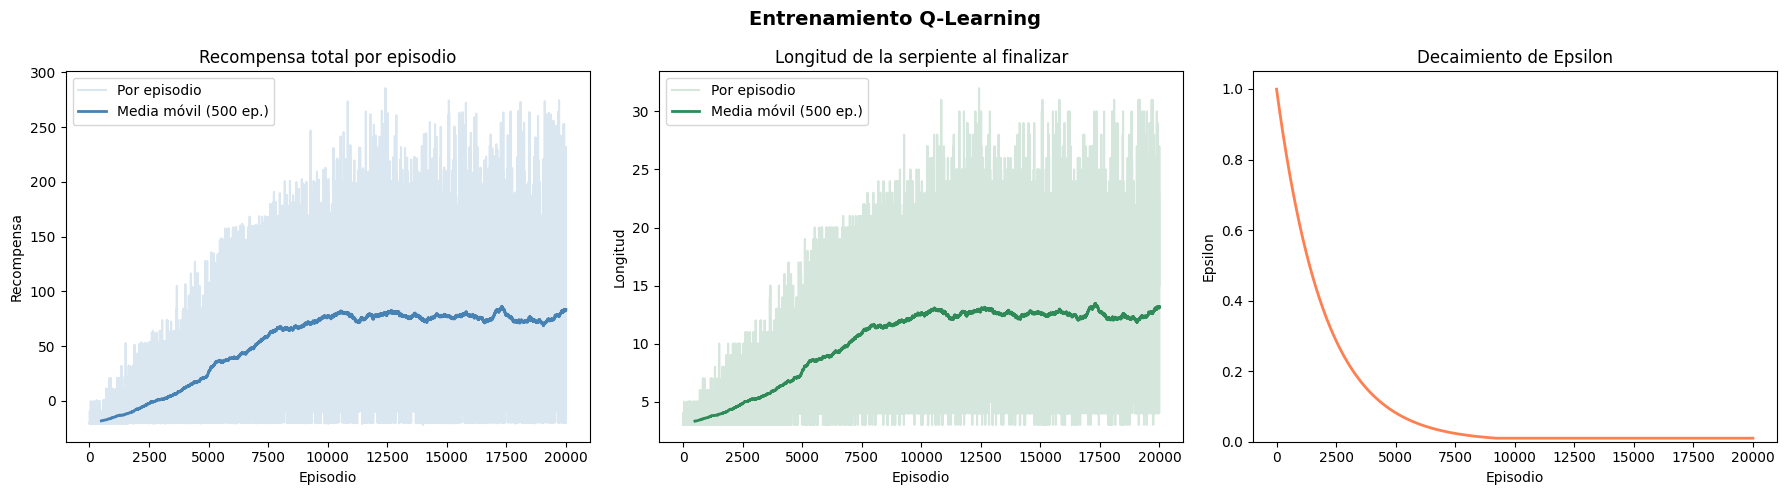

In [28]:
ventana = 500

recompensas = np.array(metricas["recompensas"])
longitudes = np.array(metricas["longitudes"])
epsilons = np.array(metricas["epsilons"])

media_movil_r = pd.Series(recompensas).rolling(window=ventana).mean()
media_movil_l = pd.Series(longitudes).rolling(window=ventana).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Entrenamiento Q-Learning", fontsize=14, fontweight='bold')

axes[0].plot(recompensas, alpha=0.2, color='steelblue', label='Por episodio')
axes[0].plot(media_movil_r, color='steelblue', linewidth=2,
             label=f'Media móvil ({ventana} ep.)')
axes[0].set_title('Recompensa total por episodio')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa')
axes[0].legend()

axes[1].plot(longitudes, alpha=0.2, color='seagreen', label='Por episodio')
axes[1].plot(media_movil_l, color='seagreen', linewidth=2,
             label=f'Media móvil ({ventana} ep.)')
axes[1].set_title('Longitud de la serpiente al finalizar')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Longitud')
axes[1].legend()

axes[2].plot(epsilons, color='coral', linewidth=2)
axes[2].set_title('Decaimiento de Epsilon')
axes[2].set_xlabel('Episodio')
axes[2].set_ylabel('Epsilon')
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


### Visualización de como juega el Agente

In [29]:
epsilon_guardado = agente.epsilon
agente.epsilon = 0.0 # Sin exploración

env_vis = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
obs, _ = env_vis.reset()

recompensa_total = 0.0
episodio = 1

print("Agente Q-Learning jugando. Pulsa ESC o cierra la ventana para salir.")
print(f"{'Episodio':>9} | {'Recompensa':>10} | {'Longitud':>8} | Causa fin")
print("-" * 55)

while env_vis.running:
    accion = agente.get_accion(obs)
    obs, recompensa, terminado, truncado, info = env_vis.step(accion)
    recompensa_total += recompensa
    env_vis.render()

    if terminado or truncado:
        causa = info.get("cause") or "max_steps"
        print(f"{episodio:>9} | {recompensa_total:>10.2f} | {len(env_vis.snake):>8} | {causa}")
        episodio += 1
        recompensa_total = 0.0
        obs, _ = env_vis.reset()

env_vis.close()
agente.epsilon = epsilon_guardado   # Restaurar epsilon original
print("\nVisualización cerrada.")

Agente Q-Learning jugando. Pulsa ESC o cierra la ventana para salir.
 Episodio | Recompensa | Longitud | Causa fin
-------------------------------------------------------
        1 |     217.96 |       26 | collision
        2 |      32.79 |        8 | collision

Visualización cerrada.


## Deep Q-learning

En primer lugar definimos dos clases:
* **QNetwork**: se trata de la red neuronal que utilizará el agente. Está formada por tres capas, una capa de entrada que recibe el vector de observaciones del entorno, una capa intermedia para encontrar patrones no lineales y una capa de salida que devuelve la acción a realizar por el agente.

* **ReplayBuffer**: es la memoria de la red, guarda las transacciones (s, a, r, s', done) y devuelve muestras aleatorias para romper la correlación temporal entre experiencias consecutivas.

In [30]:
class QNetwork(nn.Module):
    def __init__(self, n_observaciones: int, n_acciones: int):
        super(QNetwork, self).__init__()

        # Red FeedForward de 3 capas con activación ReLU
        self.fc1 = nn.Linear(n_observaciones, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, n_acciones)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x) # Valores Q lineales, sin activación final
    


class ReplayBuffer:
    def __init__(self, capacidad: int):
        self.memoria = deque(maxlen=capacidad)

    def guardar(self, estado, accion, recompensa, estado_siguiente, terminado):
        self.memoria.append((estado, accion, recompensa, estado_siguiente, terminado))

    def samplear(self, tamano_lote: int):
        lote = random.sample(self.memoria, tamano_lote)
        estados, acciones, recompensas, estados_siguientes, terminados = zip(*lote)

        return (
            torch.tensor(np.array(estados), dtype=torch.float32).to(device),
            torch.tensor(acciones, dtype=torch.int64).unsqueeze(1).to(device),
            torch.tensor(recompensas, dtype=torch.float32).unsqueeze(1).to(device),
            torch.tensor(np.array(estados_siguientes), dtype=torch.float32).to(device),
            torch.tensor(terminados, dtype=torch.float32).unsqueeze(1).to(device))

    def __len__(self):
        return len(self.memoria)

Ahora, implementamos el agente DQN:
* **AgenteDQN**: es una clase que contiene las dos redes neuronales necesarias para el entrenamiento: *Policy Net*, que se entrena en cada paso; y *Target Net*, es la red congelada que se actualiza cada N episodios.

* **entrenamiento_DQN**: es la función principal para realizar el entrenamiento del agente. Entrena el agente durante un número fijo de episodios y devuelve una instancia del agente entrenado y un diccionario con algunas métricas del entrenamiento.

In [31]:
class AgenteDQN:
    def __init__(self, env):
        self.n_observaciones = env.observation_space.shape[0]
        self.n_acciones = env.action_space.n

        # Hiperparámetros
        self.lote_size = 128
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.lr = 1e-3

        # Red principal (policy net) y red objetivo (target net)
        self.policy_net = QNetwork(self.n_observaciones, self.n_acciones).to(device)
        self.target_net = QNetwork(self.n_observaciones, self.n_acciones).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict()) # Mismos pesos iniciales
        self.target_net.eval() # La target net nunca entrena directamente

        self.optimizador = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.memoria = ReplayBuffer(capacidad=10_000)

    def get_accion(self, estado: np.ndarray) -> int:
        """Política epsilon-greedy: explora o explota según el epsilon."""
        if random.random() < self.epsilon:
            return random.randrange(self.n_acciones) # Exploración aleatoria
        else:
            with torch.no_grad():
                estado_tensor = torch.tensor(estado, dtype=torch.float32).unsqueeze(0).to(device)
                q_valores = self.policy_net(estado_tensor)
                return q_valores.argmax().item() # Explotación: máxima Q

    def entrenar_red(self):
        """
        Aprende de un mini-lote aleatorio del replay buffer.
        Implementa la ecuación de Bellman con la target network:

        objetivo_TD = r + y · max_a' Q_target(s', a')
        loss = MSE(Q_policy(s, a), objetivo_TD)
        """
        # No entrenamos hasta tener suficientes experiencias
        if len(self.memoria) < self.lote_size:
            return

        estados, acciones, recompensas, estados_siguientes, terminados = \
            self.memoria.samplear(self.lote_size)

        # Q(s, a) actual según la policy net
        q_actuales = self.policy_net(estados).gather(1, acciones)

        # max Q(s', a') según la target net
        with torch.no_grad():
            q_futuros   = self.target_net(estados_siguientes).max(1)[0].unsqueeze(1)
            objetivo_td = recompensas + (self.gamma * q_futuros * (1 - terminados))

        # Loss MSE
        loss = F.mse_loss(q_actuales, objetivo_td)

        # Backpropagation
        self.optimizador.zero_grad()
        loss.backward()
        self.optimizador.step()

    def actualizar_target_network(self):
        """Copia los pesos de la policy net a la target net."""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        """Reduce epsilon multiplicativamente respetando el mínimo."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)



def entrenamiento_DQN(env, num_episodios = 500, intervalo_target_net = 10, intervalo_log = 50) -> tuple[AgenteDQN, dict]:
    """
    Entrena un agente DQN en el entorno dado. Devuelve el agente entrenado y
    las métricas de entrenamiento.

    intervalo_target_net: cada cuántos episodios actualizar la target network
    """
    agente = AgenteDQN(env)

    metricas = {
        "recompensas": [],
        "longitudes": [],
        "causas": [],
        "epsilons": [],
    }

    print(f"{'Episodio':>10} | {'R. Media':>10} | {'Long. Media':>12} | {'Epsilon':>8}")
    print("-" * 50)

    for ep in range(1, num_episodios + 1):
        obs, _ = env.reset()
        recompensa_total = 0.0
        terminado = truncado = False

        while not (terminado or truncado):
            # Elige una acción
            accion = agente.get_accion(obs)

            # Ejecuta la acción en el entorno
            obs_sig, recompensa, terminado, truncado, info = env.step(accion)

            # Guarda la transición en el replay buffer
            agente.memoria.guardar(obs, accion, recompensa, obs_sig, terminado or truncado)

            # Aprende de un mini-lote aleatorio del pasado
            agente.entrenar_red()

            obs = obs_sig
            recompensa_total += recompensa

        # Decaer epsilon al final del episodio
        agente.decay_epsilon()

        # Actualizar target network cada intervalo_target_net episodios
        if ep % intervalo_target_net == 0:
            agente.actualizar_target_network()

        # Guardar métricas
        metricas["recompensas"].append(recompensa_total)
        metricas["longitudes"].append(len(env.snake))
        metricas["causas"].append(info.get("cause") or "max_steps")
        metricas["epsilons"].append(agente.epsilon)

        # Log de progreso
        if ep % intervalo_log == 0:
            ventana_r = metricas["recompensas"][-intervalo_log:]
            ventana_l = metricas["longitudes"][-intervalo_log:]
            print(
                f"{ep:>10} | "
                f"{np.mean(ventana_r):>10.2f} | "
                f"{np.mean(ventana_l):>12.2f} | "
                f"{agente.epsilon:>8.4f}"
            )

    print("\nEntrenamiento finalizado.")
    return agente, metricas

### Entrenamiento del modelo
Al igual que en Q-Learning, entrenamos un agente con decaimiento del parámetro *epsilon* para explorar inicialmente y después refinar las mejores estrategias encontradas.

In [32]:
env = SnakeEnv(grid_size=10, render_mode=None, max_steps=500)

agente_dqn, metricas_dqn = entrenamiento_DQN(
    env,
    num_episodios = 3000,
    intervalo_target_net = 20, # Actualiza la target net cada 20 episodios
    intervalo_log = 100,
)

  Episodio |   R. Media |  Long. Media |  Epsilon
--------------------------------------------------
       100 |     -17.10 |         3.39 |   0.6058
       200 |     -10.05 |         4.09 |   0.3670
       300 |      -1.40 |         4.94 |   0.2223
       400 |      10.49 |         6.13 |   0.1347
       500 |      26.81 |         7.61 |   0.0816
       600 |      43.61 |         9.29 |   0.0494
       700 |      54.32 |        10.40 |   0.0299
       800 |      55.23 |        10.50 |   0.0181
       900 |      74.60 |        12.27 |   0.0110
      1000 |      78.98 |        12.75 |   0.0100
      1100 |      80.20 |        12.90 |   0.0100
      1200 |      74.42 |        12.36 |   0.0100
      1300 |      75.94 |        12.43 |   0.0100
      1400 |      80.83 |        12.93 |   0.0100
      1500 |      70.50 |        11.93 |   0.0100
      1600 |      87.68 |        13.60 |   0.0100
      1700 |      77.09 |        12.55 |   0.0100
      1800 |      64.60 |        11.45 |   0.0100

### Evolución del entrenamiento
Una vez entrenado el agente, vamos a visualizar la evolución del entrenamiento con la recompensa obtenida, longitud de la serpiente y decaimiento del parámetro *epsilon* a lo largo de los episodios:

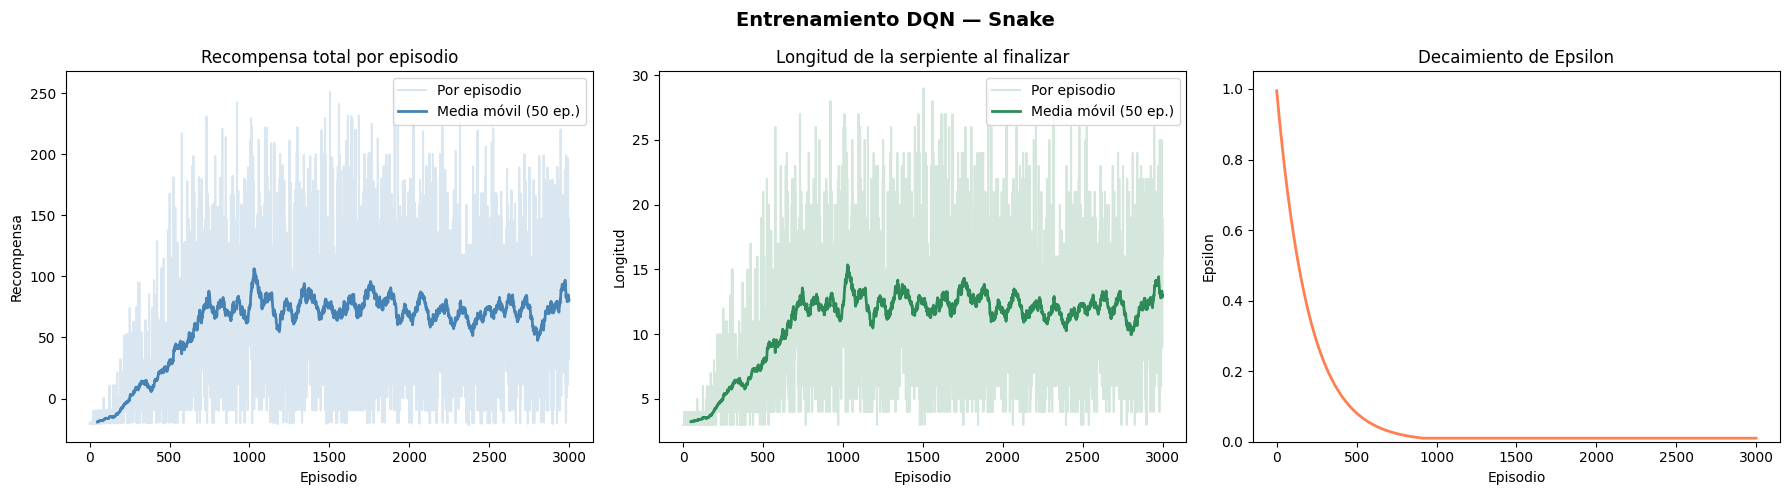

In [ ]:
ventana = 50

recompensas = np.array(metricas_dqn["recompensas"])
longitudes = np.array(metricas_dqn["longitudes"])
epsilons = np.array(metricas_dqn["epsilons"])

media_movil_r = pd.Series(recompensas).rolling(window=ventana).mean()
media_movil_l = pd.Series(longitudes).rolling(window=ventana).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Entrenamiento DQN — Snake", fontsize=14, fontweight='bold')

axes[0].plot(recompensas, alpha=0.2, color='steelblue', label='Por episodio')
axes[0].plot(media_movil_r, color='steelblue', linewidth=2,
             label=f'Media móvil ({ventana} ep.)')
axes[0].set_title('Recompensa total por episodio')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa')
axes[0].legend()

axes[1].plot(longitudes, alpha=0.2, color='seagreen', label='Por episodio')
axes[1].plot(media_movil_l, color='seagreen', linewidth=2,
             label=f'Media móvil ({ventana} ep.)')
axes[1].set_title('Longitud de la serpiente al finalizar')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Longitud')
axes[1].legend()

axes[2].plot(epsilons, color='coral', linewidth=2)
axes[2].set_title('Decaimiento de Epsilon')
axes[2].set_xlabel('Episodio')
axes[2].set_ylabel('Epsilon')
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


### Visualización del agente jugando


In [ ]:
env_vis = SnakeEnv(grid_size=10, render_mode="human", cell_size=50)
obs, _ = env_vis.reset()

recompensa_total = 0.0
episodio = 1

print("Agente DQN jugando. Pulsa ESC o cierra la ventana para salir.")
print(f"{'Episodio':>9} | {'Recompensa':>10} | {'Longitud':>8} | Causa fin")
print("-" * 55)

while env_vis.running:
    # Evaluación en modo codicioso: sin exploración
    with torch.no_grad():
        estado_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
        accion = agente_dqn.policy_net(estado_tensor).argmax().item()

    obs, recompensa, terminado, truncado, info = env_vis.step(accion)
    recompensa_total += recompensa
    env_vis.render()

    if terminado or truncado:
        causa = info.get("cause") or "max_steps"
        print(f"{episodio:>9} | {recompensa_total:>10.2f} | {len(env_vis.snake):>8} | {causa}")
        episodio += 1
        recompensa_total = 0.0
        obs, _ = env_vis.reset()

env_vis.close()

Agente DQN jugando. Pulsa ESC o cierra la ventana para salir.
 Episodio | Recompensa | Longitud | Causa fin
-------------------------------------------------------
        1 |      63.25 |       11 | collision
        2 |     179.21 |       23 | bad_food


## Mejoras sobre DQN estándar
Para terminar, vamos a probar dos mejoras del método DQN estándar para intentar ver si podemos mejorar los resultados obtenidos.

### Mejora 1 — Double DQN
En el DQN estándar, el objetivo TD se calculaba como:

$$r + \gamma \cdot \max_{a'} Q_{\text{target}}(s', a')$$

La misma red target selecciona y evalúa la acción, acumulando error. Double DQN separa estas dos responsabilidades entre las dos redes ya
existentes:

$$r + \gamma \cdot Q_{\text{target}}\bigl(s',\, \arg\max_{a'} Q_{\text{policy}}(s', a')\bigr)$$

- La **policy net** selecciona qué acción es la mejor en $s'$
- La **target net** evalúa el valor de esa acción

Esto elimina el sesgo de sobreestimación sin añadir coste computacional ni parámetros adicionales.
<br><br>

---

### Mejora 2 — Dueling DQN

En el DQN estándar, la red aprende un único valor $Q(s, a)$ para cada par estado-acción. En el juego del Snake, lo que determina el resultado es la calidad del estado.

Con esta mejora, se descompone el valor Q en dos componentes permitiendo que la red aprenda el valor de los estados de forma más eficiente. Las dos componentes son:

$$Q(s, a) = V(s) + A(s, a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s, a')$$

- $V(s)$: **función de valor** — cuánta recompensa futura se espera desde el estado $s$, independientemente de la acción
- $A(s, a)$: **función de ventaja** — cuánto mejor es la acción $a$ respecto a la media de acciones en ese estado

In [ ]:
class QNetworkMejorada(nn.Module):
    def __init__(self, n_observaciones: int, n_acciones: int):
        super(QNetworkMejorada, self).__init__()
        self.fc1 = nn.Linear(n_observaciones, 128)
        self.fc2 = nn.Linear(128, 128)

        # Cabeza V(s)
        self.valor = nn.Linear(128, 1)

        # Cabeza A(s, a)
        self.ventaja = nn.Linear(128, n_acciones)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        v = self.valor(x)
        a = self.ventaja(x)

        # Q(s,a) = V(s) + A(s,a) - mean(A)
        return v + a - a.mean(dim=1, keepdim=True)


class AgenteDQNMejorado:
    def __init__(self, env):
        self.n_observaciones = env.observation_space.shape[0]
        self.n_acciones      = env.action_space.n

        self.lote_size = 128
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.lr = 1e-3

        self.policy_net = QNetworkMejorada(self.n_observaciones, self.n_acciones).to(device)
        self.target_net = QNetworkMejorada(self.n_observaciones, self.n_acciones).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizador = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.memoria = ReplayBuffer(capacidad=50_000)

    def get_accion(self, estado: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randrange(self.n_acciones)
        else:
            with torch.no_grad():
                estado_tensor = torch.tensor(estado, dtype=torch.float32).unsqueeze(0).to(device)
                return self.policy_net(estado_tensor).argmax().item()

    def entrenar_red(self):
        if len(self.memoria) < self.lote_size:
            return
        estados, acciones, recompensas, estados_siguientes, terminados = \
            self.memoria.samplear(self.lote_size)
        q_actuales = self.policy_net(estados).gather(1, acciones)
        with torch.no_grad():
            mejores_acciones = self.policy_net(estados_siguientes).argmax(1).unsqueeze(1)
            q_futuros = self.target_net(estados_siguientes).gather(1, mejores_acciones)
            objetivo_td = recompensas + (self.gamma * q_futuros * (1 - terminados))
        loss = F.mse_loss(q_actuales, objetivo_td)
        self.optimizador.zero_grad()
        loss.backward()
        self.optimizador.step()

    def actualizar_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

### Comparación con DQN
Entrenamos el agente DQN añadiendo las dos mejoras que hemos implementado:

In [ ]:
NUM_EPISODIOS = 3_000

# DQN estándar ya entrenado anteriormente
env = SnakeEnv(grid_size=10, render_mode=None, max_steps=500)
agente_dqn, metricas_dqn = entrenamiento_DQN(
    env,
    num_episodios = NUM_EPISODIOS,
    intervalo_target_net = 20,
    intervalo_log = 100,
)



# DQN mejorado (Dueling + Double)
def entrenamiento_DQN_mejorado(env, num_episodios, intervalo_target_net, intervalo_log):
    agente = AgenteDQNMejorado(env)
    metricas = {"recompensas": [], "longitudes": [], "epsilons": []}

    print(f"{'Episodio':>10} | {'R. Media':>10} | {'Long. Media':>12} | {'Epsilon':>8}")
    print("-" * 50)

    for ep in range(1, num_episodios + 1):
        obs, _           = env.reset()
        recompensa_total = 0.0
        terminado = truncado = False

        while not (terminado or truncado):
            accion = agente.get_accion(obs)
            obs_sig, recompensa, terminado, truncado, info = env.step(accion)
            agente.memoria.guardar(obs, accion, recompensa, obs_sig, terminado or truncado)
            agente.entrenar_red()
            obs               = obs_sig
            recompensa_total += recompensa

        agente.decay_epsilon()

        if ep % intervalo_target_net == 0:
            agente.actualizar_target_network()

        metricas["recompensas"].append(recompensa_total)
        metricas["longitudes"].append(len(env.snake))
        metricas["epsilons"].append(agente.epsilon)

        if ep % intervalo_log == 0:
            ventana_r = metricas["recompensas"][-intervalo_log:]
            ventana_l = metricas["longitudes"][-intervalo_log:]
            print(f"{ep:>10} | {np.mean(ventana_r):>10.2f} | "
                  f"{np.mean(ventana_l):>12.2f} | {agente.epsilon:>8.4f}")

    print("\nEntrenamiento finalizado.")
    return agente, metricas

env_mejorado = SnakeEnv(grid_size=10, render_mode=None, max_steps=500)
agente_dqn_mejorado, metricas_dqn_mejorado = entrenamiento_DQN_mejorado(
    env_mejorado,
    num_episodios = NUM_EPISODIOS,
    intervalo_target_net = 20,
    intervalo_log = 100,
)

  Episodio |   R. Media |  Long. Media |  Epsilon
--------------------------------------------------
       100 |     -17.65 |         3.38 |   0.6058
       200 |      -8.77 |         4.23 |   0.3670
       300 |       1.53 |         5.20 |   0.2223
       400 |       7.35 |         5.79 |   0.1347
       500 |      21.52 |         7.19 |   0.0816
       600 |      38.89 |         8.84 |   0.0494
       700 |      47.43 |         9.69 |   0.0299
       800 |      62.68 |        11.22 |   0.0181
       900 |      65.36 |        11.48 |   0.0110
      1000 |      76.55 |        12.50 |   0.0100
      1100 |      86.90 |        13.48 |   0.0100
      1200 |      83.43 |        13.19 |   0.0100
      1300 |      87.06 |        13.51 |   0.0100
      1400 |      83.92 |        13.19 |   0.0100
      1500 |      80.00 |        12.84 |   0.0100
      1600 |      83.13 |        13.08 |   0.0100
      1700 |      74.55 |        12.37 |   0.0100
      1800 |      77.60 |        12.56 |   0.0100

### Gráfica comparativa

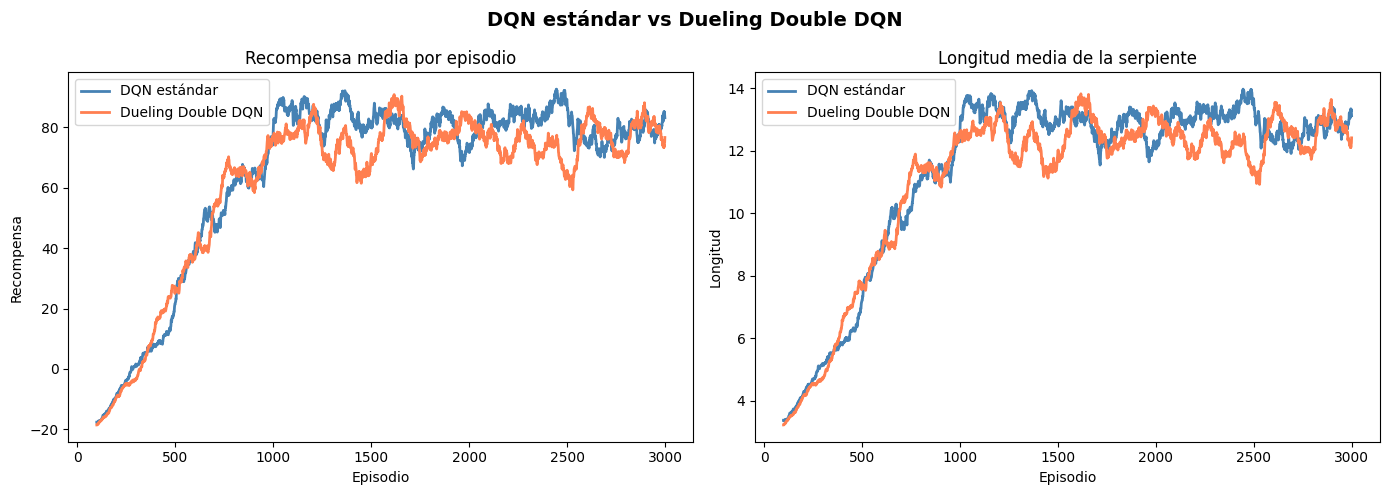

In [ ]:
ventana = 100

r_dqn = pd.Series(metricas_dqn["recompensas"]).rolling(window=ventana).mean()
r_mejorado = pd.Series(metricas_dqn_mejorado["recompensas"]).rolling(window=ventana).mean()

l_dqn = pd.Series(metricas_dqn["longitudes"]).rolling(window=ventana).mean()
l_mejorado = pd.Series(metricas_dqn_mejorado["longitudes"]).rolling(window=ventana).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DQN estándar vs Dueling Double DQN", fontsize=14, fontweight='bold')

axes[0].plot(r_dqn, color='steelblue', linewidth=2, label='DQN estándar')
axes[0].plot(r_mejorado, color='coral', linewidth=2, label='Dueling Double DQN')
axes[0].set_title('Recompensa media por episodio')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa')
axes[0].legend()

axes[1].plot(l_dqn, color='steelblue', linewidth=2, label='DQN estándar')
axes[1].plot(l_mejorado, color='coral', linewidth=2, label='Dueling Double DQN')
axes[1].set_title('Longitud media de la serpiente')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Longitud')
axes[1].legend()

plt.tight_layout()
plt.show()